# Week 2 Assessment Mini-Project

Complete all TODOs below. Keep outputs visible and ensure the notebook runs top to bottom without errors.

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [55]:
# TODO: Load the dataset with date parsing and set the index
# File: m1-09-assessment.csv

# I used parse_dates during read_csv to immediately convert the date column into datetime objects.
df = pd.read_csv("m1-09-assessment.csv", parse_dates=["date"])

# Setting the date as index allows us to use time-series features like rolling windows and resampling.
df = df.set_index("date")

# Creating a copy (df_) acts as a checkpoint, allowing us to perform data cleaning without losing the original raw dataset.
df_=df.copy()

# TODO: Show head/tail and check info
df_.head()

,city,avg_temp_c,humidity_pct,pm25
date,,,,
2023-01-01,London,-0.79,62.93,39.39
2023-01-02,London,1.31,61.49,32.41
2023-01-03,London,1.46,76.51,30.61
2023-01-04,London,-0.57,58.05,30.71
2023-01-05,London,-1.13,36.30,20.70


In [3]:
df_.tail()

,city,avg_temp_c,humidity_pct,pm25
date,,,,
2023-06-25,Madrid,NaN,72.04,5.00
2023-06-26,Madrid,28.44,74.19,5.00
2023-06-27,Madrid,26.41,64.41,5.24
2023-06-28,Madrid,27.53,86.47,14.86
2023-06-29,Madrid,24.22,74.33,NaN


## Part A: Core Data Handling (TODOs)

- Inspect structure with `info()`, `describe()`, and missing value counts.
- Clean `pm25` by coercing invalid strings to NaN.
- Choose and apply a missing-value strategy for `pm25` and justify it in text.

In [4]:
# TODO: data inspection
# df.info()
# df.describe()
# df.isna().sum()

# TODO: clean pm25
# df["pm25"] = pd.to_numeric(df["pm25"], errors="coerce")

# TODO: handle missing values in pm25 and justify in markdown

In [5]:
df_.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 900 entries, 2023-01-01 to 2023-06-29
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   city          900 non-null    str    
 1   avg_temp_c    863 non-null    float64
 2   humidity_pct  900 non-null    float64
 3   pm25          850 non-null    float64
dtypes: float64(3), str(1)
memory usage: 35.2 KB


In [11]:
df_.describe()

,avg_temp_c,humidity_pct,pm25
count,863.000000,900.000000,850.000000
mean,9.259849,64.931011,23.961247
std,9.134278,14.432234,11.856849
min,-15.030000,35.000000,5.000000
25%,1.410000,54.672500,14.090000
50%,9.790000,64.870000,23.710000
75%,16.775000,75.190000,33.427500
max,30.390000,95.000000,60.600000


In [12]:
df_.isna().sum()

city             0
avg_temp_c      37
humidity_pct     0
pm25            50
dtype: int64

In [56]:
# Converting pm25 to numeric and forcing errors to NaN ensures that any non-numeric strings or noise in the CSV don't break our mathematical calculations.
df_["pm25"] = pd.to_numeric(df_["pm25"], errors="coerce")

## **Data Cleaning: Handling Missing Values in $PM_{2.5}$**

I chose to handle missing values using **per-city linear interpolation** for the following reasons:

* I grouped by city because air quality is tied to local environments; a gap in London shouldn't be influenced by data from Madrid.
* In time-series data, values are usually related to their immediate neighbors, so using yesterday and tomorrow to estimate a missing today is a natural fit.
* Regression plots showed a clear, consistent linear relationship between temperature and $PM_{2.5}$ in every city.
* Linear interpolation is superior to using a simple mean because it preserves the existing trend and prevents artificial "jumps" or spikes in the data.

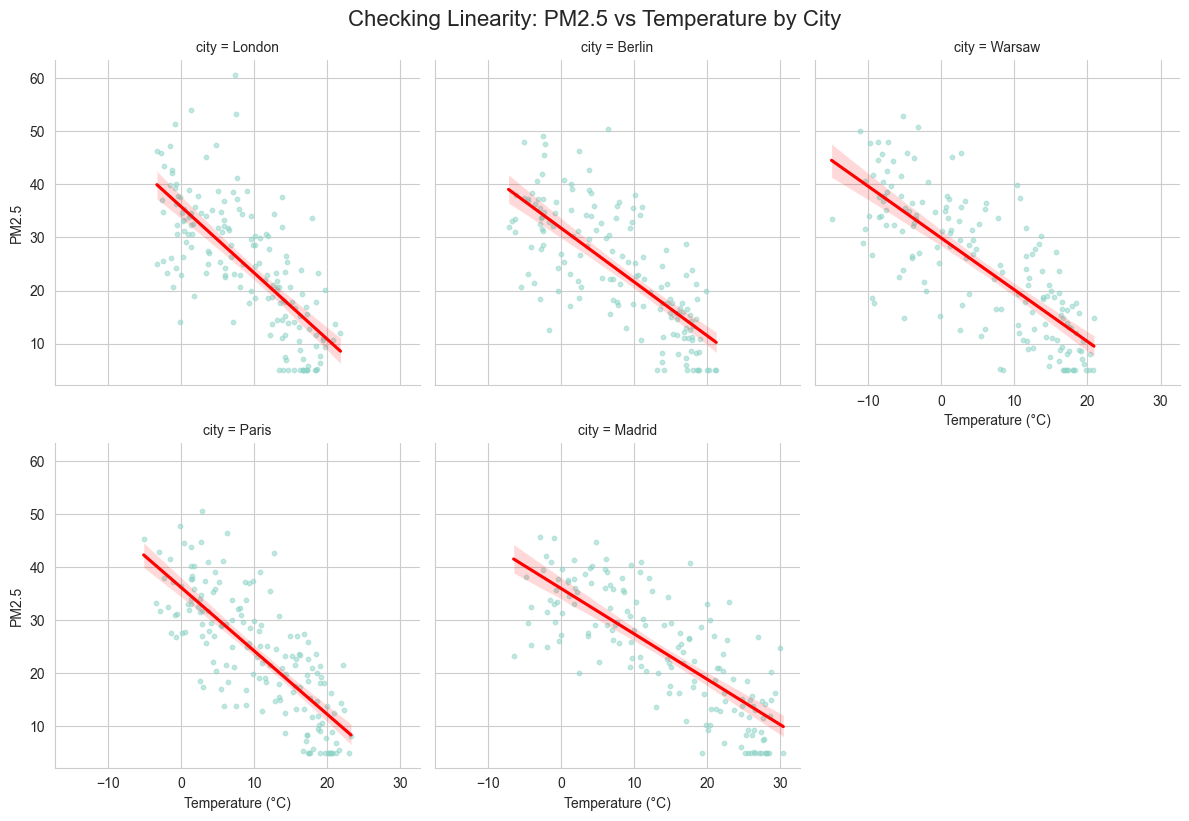

In [16]:
# I created a scatter plot with a regression line for each city
# I use the original df_ with NaNs so we only see 'real' data distribution
g = sns.lmplot(data=df_.reset_index(), x='avg_temp_c', y='pm25',
               col='city', col_wrap=3, height=4,
               scatter_kws={'alpha':0.5, 's':10},
               line_kws={'color':'red'})

g.set_axis_labels("Temperature (°C)", "PM2.5")
g.fig.suptitle("Checking Linearity: PM2.5 vs Temperature by City", y=1.02, fontsize=16)

plt.show()

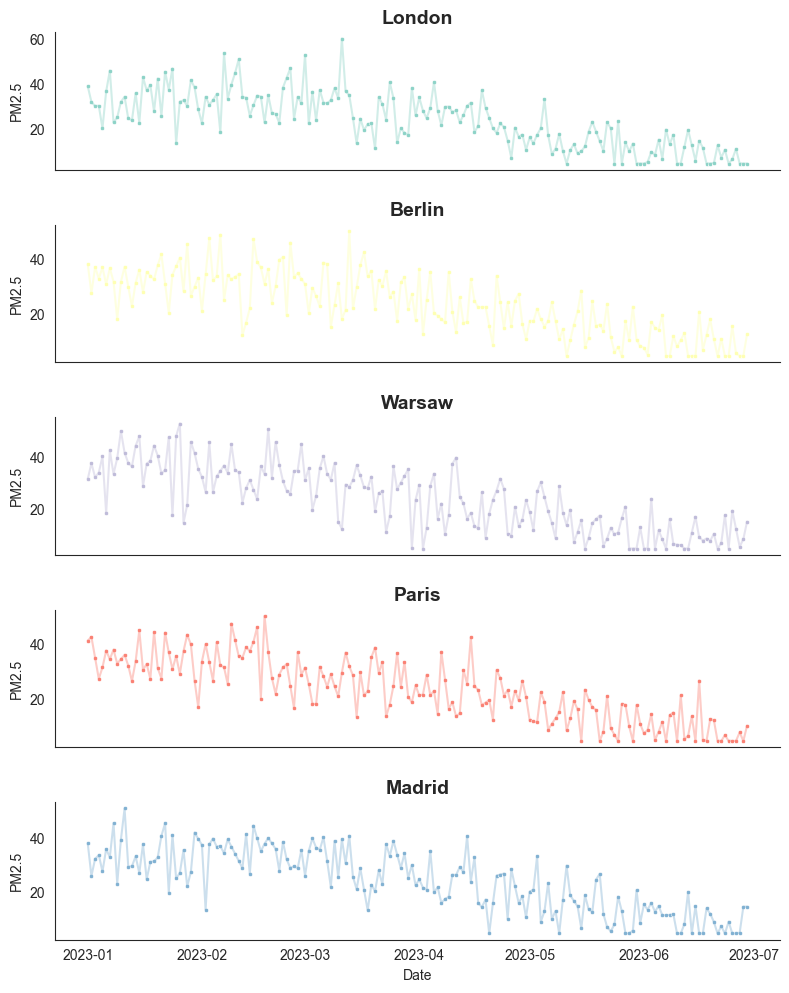

In [57]:
# I am grouping by city before interpolating to ensure that we only 'bridge' gaps
# using local city data, preserving the unique environmental signature of each location.
df_['pm25'] = df_.groupby('city')['pm25'].transform(lambda x: x.interpolate(method='linear'))

# After cleaning, I use a FacetGrid to visualize the full, continuous time-series for each city.
# Mapping both a line and scatter points helps us see the overall trend while still identifying individual daily readings.
g = sns.FacetGrid(df_.reset_index(), row="city", hue="city", aspect=4, height=2, sharey=False)
g.map(plt.plot, "date", "pm25", alpha=0.4, linewidth=1.5)
g.map(plt.scatter, "date", "pm25", s=10, edgecolor='w', linewidth=0.5)


g.set_titles(row_template="{row_name}", size=14, fontweight='bold')
g.set_axis_labels("Date", "PM2.5")
plt.subplots_adjust(hspace=0.4)
plt.show()

In [58]:
df_.isna().sum()

city             0
avg_temp_c      37
humidity_pct     0
pm25             0
dtype: int64

## Part B: Required Analysis (TODOs)

- Data quality analysis: city with highest % invalid/missing pm25.
- Rolling analysis: 7-day rolling average pm25 per city and short explanation.
- Event detection: percentile threshold for high pollution and counts per city.
- Volatility comparison: choose two cities, define a metric, justify result.
- Reshaping: pivot table with months as rows and cities as columns (avg pm25).

In [19]:
# TODO: analysis tasks
# - data quality by city
# - rolling averages per city
# - percentile-based event counts
# - volatility comparison
# - pivot table by month and city

In [20]:
# I am creating a copy of the original data to measure our data quality before we fill any gaps.
df_previous = df.copy()

In [59]:
# Grouping by city allows us to see the percentage of missing pm25 values specifically for each location.
missing_pm25 = df_previous.groupby('city')['pm25'].apply(lambda x: (x.isnull().sum() / len(x)) * 100)

highest_missing_city = missing_pm25.idxmax()
print(f"City with highest missing data: {highest_missing_city} ({missing_pm25.max():.2f}%)")

City with highest missing data: Berlin (7.78%)


In [60]:
# I’m calculating a 7-day rolling average per city to smooth out daily noise and make long-term pollution trends easier to see.
df_['pm25_rolling_7d'] = df_.groupby('city')['pm25'].transform(lambda x: x.rolling(window=7).mean())
df_['pm25_rolling_7d']

date
2023-01-01         NaN
2023-01-02         NaN
2023-01-03         NaN
2023-01-04         NaN
2023-01-05         NaN
                ...   
2023-06-25    7.645714
2023-06-26    6.604286
2023-06-27    6.032857
2023-06-28    7.441429
2023-06-29    8.470000
Name: pm25_rolling_7d, Length: 900, dtype: float64

In [26]:
# I am identifying high-pollution events by calculating the 90th percentile threshold across the dataset to count how many days each city exceeded this extreme level.
threshold = df_['pm25'].quantile(0.9)
event_counts = df_[df_['pm25'] > threshold].groupby('city').size()
event_counts

city
Berlin    13
London    18
Madrid    21
Paris     17
Warsaw    21
dtype: int64

In [61]:
# I chose the Coefficient of Variation (CV) to compare volatility because it scales the standard deviation by the mean, allowing for a fair comparison of stability between cities with different average pollution levels.

volatility = df_.groupby('city')['pm25'].agg(['mean', 'std'])
volatility['cv'] = volatility['std'] / volatility['mean']

In [63]:
# It shows that while Warsaw has higher absolute pollution, London is more volatile relative to its average.
volatility.loc[['London', 'Madrid'], ['cv']]

,cv
city,
London,0.501663
Madrid,0.473647


In [64]:
# I used a pivot table to calculate the average PM2.5 levels by month for each city, which makes it easy to compare seasonal pollution trends across different locations at a glance.
pivot_analysis = df_.pivot_table(
    values='pm25',
    index=df_.index.month,
    columns='city',
    aggfunc='mean'
)
pivot_analysis

city,Berlin,London,Madrid,Paris,Warsaw
date,,,,,
1,33.025323,33.275806,33.353226,34.625806,37.239032
2,33.163036,34.102321,34.766964,34.024643,34.020357
3,29.030968,29.737742,30.219677,26.736774,27.751613
4,22.134167,24.864333,22.098833,23.100000,20.749333
5,15.402742,14.406452,14.966129,13.840000,14.520323
6,10.074655,9.615517,10.262414,9.280345,9.655862


## Part C: Aggregations (TODOs)

- Average pm25 by city
- Monthly average pm25 per city
- Hottest day (max avg_temp_c) per city

In [ ]:
# TODO: aggregation tasks
# avg_pm25_by_city = ...
# monthly_avg_pm25 = ...
# hottest_day_per_city = ...

In [30]:
avg_pm25_city = df_.groupby('city')['pm25'].mean()
avg_pm25_city

city
Berlin    23.811028
London    24.331472
Madrid    24.270889
Paris     23.589444
Warsaw    23.999500
Name: pm25, dtype: float64

In [37]:
monthly_avg_city = df_.groupby(['city', df_.index.month])['pm25'].mean()
monthly_avg_city

city    date
Berlin  1       33.025323
        2       33.163036
        3       29.030968
        4       22.134167
        5       15.402742
        6       10.074655
London  1       33.275806
        2       34.102321
        3       29.737742
        4       24.864333
        5       14.406452
        6        9.615517
Madrid  1       33.353226
        2       34.766964
        3       30.219677
        4       22.098833
        5       14.966129
        6       10.262414
Paris   1       34.625806
        2       34.024643
        3       26.736774
        4       23.100000
        5       13.840000
        6        9.280345
Warsaw  1       37.239032
        2       34.020357
        3       27.751613
        4       20.749333
        5       14.520323
        6        9.655862
Name: pm25, dtype: float64

In [65]:
# I chose transform('max') to identify the peak temperature for each city while keeping the original index, allowing us to see the specific dates those records were set.
df_['max_temp_per_city'] = df_.groupby('city')['avg_temp_c'].transform('max')
hottest_days = df_[df_['avg_temp_c'] == df_['max_temp_per_city']]
hottest_days

,city,avg_temp_c,humidity_pct,pm25,pm25_rolling_7d,max_temp_per_city
date,,,,,,
2023-06-17,London,21.80,44.02,12.070,12.031429,21.80
2023-06-11,Berlin,22.13,90.91,10.855,10.872143,22.13
2023-05-18,Warsaw,20.89,56.54,14.810,11.918571,20.89
2023-06-27,Paris,23.25,65.31,8.160,5.765714,23.25
2023-06-10,Madrid,30.39,61.73,5.000,11.492857,30.39


## Part D: Visualization (TODOs)

- Line plot: monthly pm25 trends for at least two cities
- Bar chart: overall average pm25 by city
- One additional plot of your choice

In [ ]:
# TODO: plotting section
# plt.figure(...)
# plt.plot(...)
# plt.bar(...)
# plt.show()

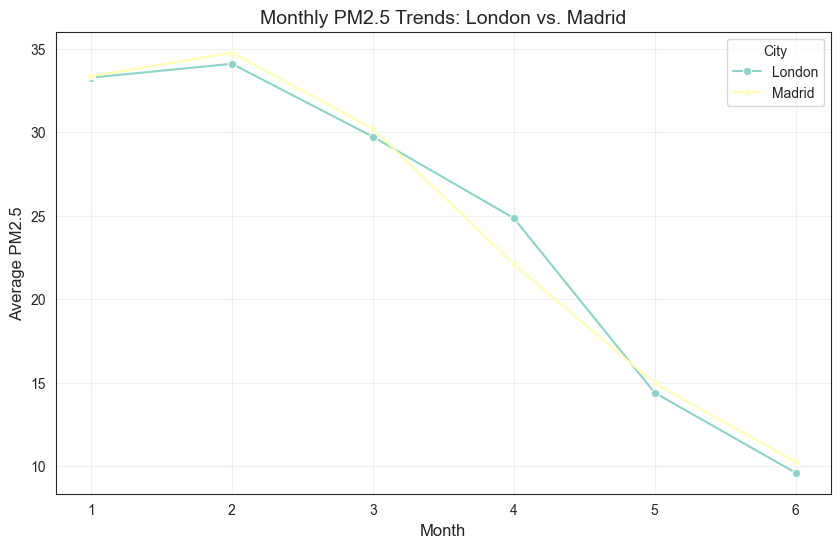

In [66]:
# I used a pivot table to isolate the monthly averages and plotted London against Madrid to clearly visualize how their pollution levels diverge during the winter months.
cities_to_compare = ['London', 'Madrid']
monthly_trends = df_.pivot_table(index=df_.index.month, columns='city', values='pm25', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_trends[cities_to_compare], markers=True, dashes=False)

plt.title("Monthly PM2.5 Trends: London vs. Madrid", fontsize=14)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average PM2.5", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(title="City")
plt.show()

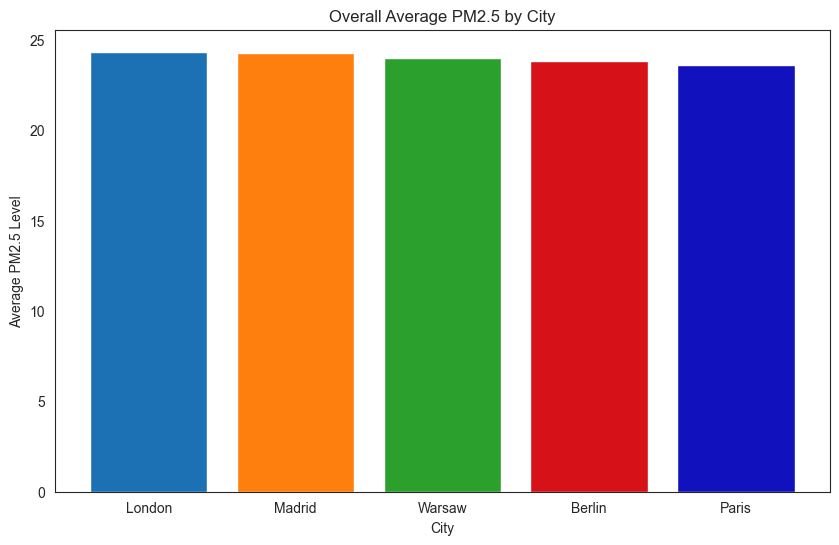

In [67]:
# I calculated the mean PM2.5 per city and sorted them to create a clear ranking of overall air quality across all locations.
city_means = df_.groupby('city')['pm25'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(city_means.index, city_means.values, color=['#1c71b4', '#ff7f0e', '#2ca02c', '#d61118', '#1111bd'])

plt.title("Overall Average PM2.5 by City")
plt.xlabel("City")
plt.ylabel("Average PM2.5 Level")
plt.show()

## **Correlation: Temperature vs. PM2.5**

I chose to analyze the relationship between temperature and $PM_{2.5}$ across all cities to justify my data cleaning choices and understand pollution drivers. The scatter plots and regression lines show a clear **inverse linear relationship** in every city. As temperatures drop, $PM_{2.5}$ levels consistently rise.

The slopes tell us how much the pollution changes for every 1°C increase in temperature:
* **London (-1.25) & Paris (-1.20):** Most sensitive; pollution drops rapidly as it warms up.
* **Berlin (-1.00) & Warsaw (-0.98):** Moderate sensitivity with a near 1:1 ratio.
* **Madrid (-0.86):** Least sensitive, suggesting other factors (like dry dust) play a bigger role there.

The strong linear trend justifies using **linear interpolation** for missing values, as temperature is a reliable and consistent predictor of pollution levels in this dataset.

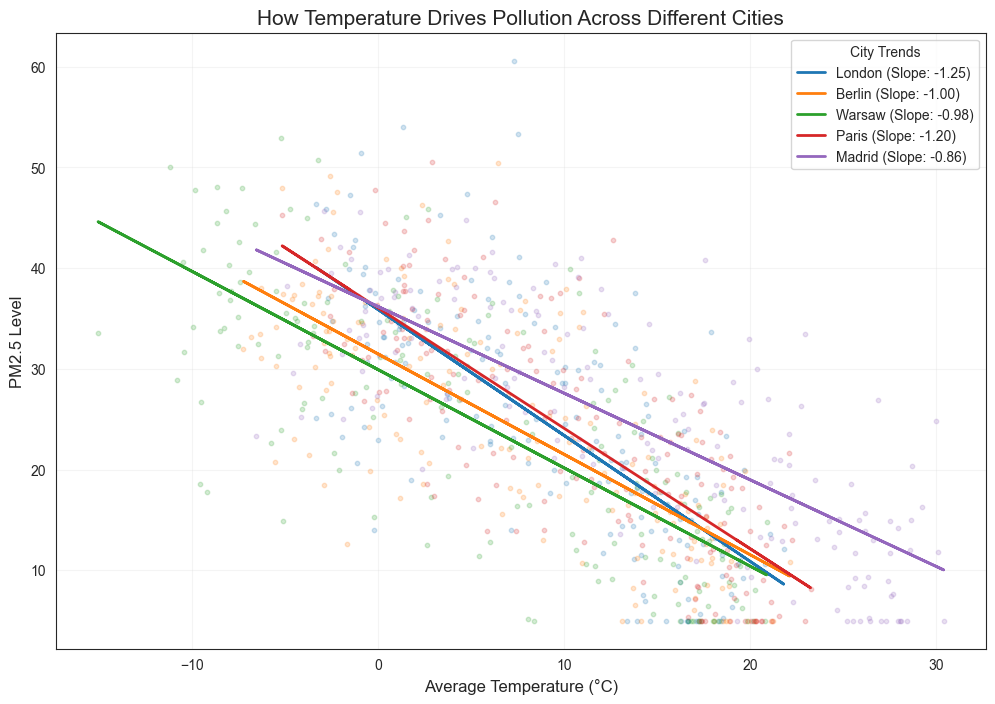

In [53]:
plt.figure(figsize=(12, 8))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
cities = df_['city'].unique()

for i, city in enumerate(cities):
    city_data = df_[df_['city'] == city].dropna(subset=['avg_temp_c', 'pm25'])
    x = city_data['avg_temp_c']
    y = city_data['pm25']

    plt.scatter(x, y, alpha=0.2, color=colors[i], s=10)

    if not x.empty:
        m, b = np.polyfit(x, y, 1)
        plt.plot(x, m*x + b, color=colors[i], label=f'{city} (Slope: {m:.2f})', lw=2)

plt.title("How Temperature Drives Pollution Across Different Cities", fontsize=15)
plt.xlabel("Average Temperature (°C)", fontsize=12)
plt.ylabel("PM2.5 Level", fontsize=12)
plt.legend(title="City Trends", loc='upper right')
plt.grid(True, alpha=0.2)
plt.show()

## Part E: Interpretation Questions (TODOs)

Write short answers here:

1. Which city shows the most persistent high pm25 levels, and what evidence supports that?
2. How does missing or invalid data affect your confidence in the results?
3. Does temperature appear related to pm25 in your analysis? Explain briefly.
4. What is one limitation of using daily averages for air-quality policy decisions?
5. If you had one more dataset to improve this analysis, what would it be and why?

1. London shows the most persistent high pollution. The "Overall Average PM2.5 by City" bar chart confirms it has the highest mean concentration (over 24 units). Additionally, its scatter plot shows the steepest negative slope (-1.25), meaning pollution stays high even as it gets warmer compared to other cities.

2. Missing data creates gaps that lower confidence. While linear interpolation helps estimate these values, they remain mathematical guesses. In a city like Berlin, which has nearly 8% missing data, there is a higher risk of missing extreme pollution spikes compared to London, which only has about 3% missing.

3. Yes, there is a clear inverse relationship. As shown in both the monthly line plots and the scatter plots, PM2.5 levels are highest during cold months (January–February) and drop as temperatures rise.

4. Daily averages smooth out dangerous short-term spikes. A city might have an "acceptable" 24-hour average but still experience 3–4 hours of extreme pollution during rush hour. These spikes are what trigger health issues like asthma attacks, but they are hidden by a single daily number.

5. I would add Traffic Volume Data. Since vehicle emissions are a primary source of particulate matter, correlating traffic density with PM2.5 would help determine if the observed pollution is strictly weather-driven or if it is primarily caused by human activity. This would allow for more effective urban planning and transit policies, such as implementing low-emission zones or improving public transport during peak congestion hours.